In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
df = pd.read_csv('online_shoppers_intention.csv')
df.dropna(inplace=True)

le = LabelEncoder()
categorical_cols = ['Month', 'VisitorType', 'Weekend', 'Revenue']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# (MLP)
model = Sequential([
    Input(shape=(X_train.shape[1],)),             
    Dense(32, activation='relu'),                 
    Dense(16, activation='relu'),            
    Dense(1, activation='sigmoid')                 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

class_weights = {0: 1., 1: 3.} 

print("Start Training....")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, class_weight=class_weights)

Start Training....
Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7874 - loss: 0.6812 - val_accuracy: 0.8647 - val_loss: 0.3773
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8800 - loss: 0.5405 - val_accuracy: 0.8804 - val_loss: 0.3224
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8863 - loss: 0.5105 - val_accuracy: 0.8844 - val_loss: 0.3096
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8877 - loss: 0.4920 - val_accuracy: 0.8855 - val_loss: 0.3017
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8862 - loss: 0.4775 - val_accuracy: 0.8890 - val_loss: 0.2969
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8887 - loss: 0.4664 - val_accuracy: 0.8708 - val_loss: 0.3075
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8846 - loss: 0.4596 - val_accuracy: 0.8875 - val_loss: 0.2884
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8873 - loss: 0.4540

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2055
           1       0.59      0.75      0.66       411

    accuracy                           0.87      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.87      0.88      2466



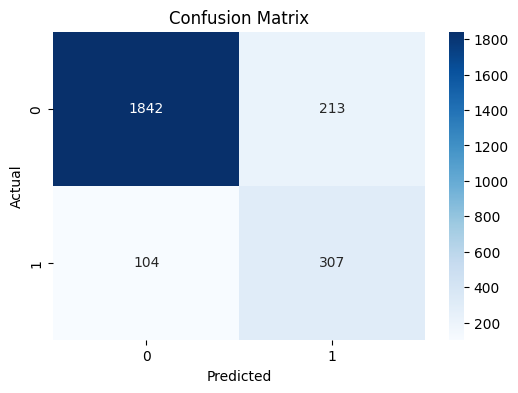


✓ Model saved: online_shoppers_model.keras
✓ Scaler saved: scaler.pkl
✓ Both model and scaler are ready for production deployment!


In [5]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ==================== PRODUCTION DEPLOYMENT ====================
# Task 1: Save Model and Scaler for Backend Deployment

# Save the trained model
model.save('online_shoppers_model.keras')
print("\n✓ Model saved: online_shoppers_model.keras")

# Save the Scaler for preprocessing new customer data
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved: scaler.pkl")
print("✓ Both model and scaler are ready for production deployment!")



🔍 Analyzing feature importance with SHAP...
This helps answer: WHY does the model predict purchase?

🌟 FEATURE IMPORTANCE VISUALIZATION 🌟


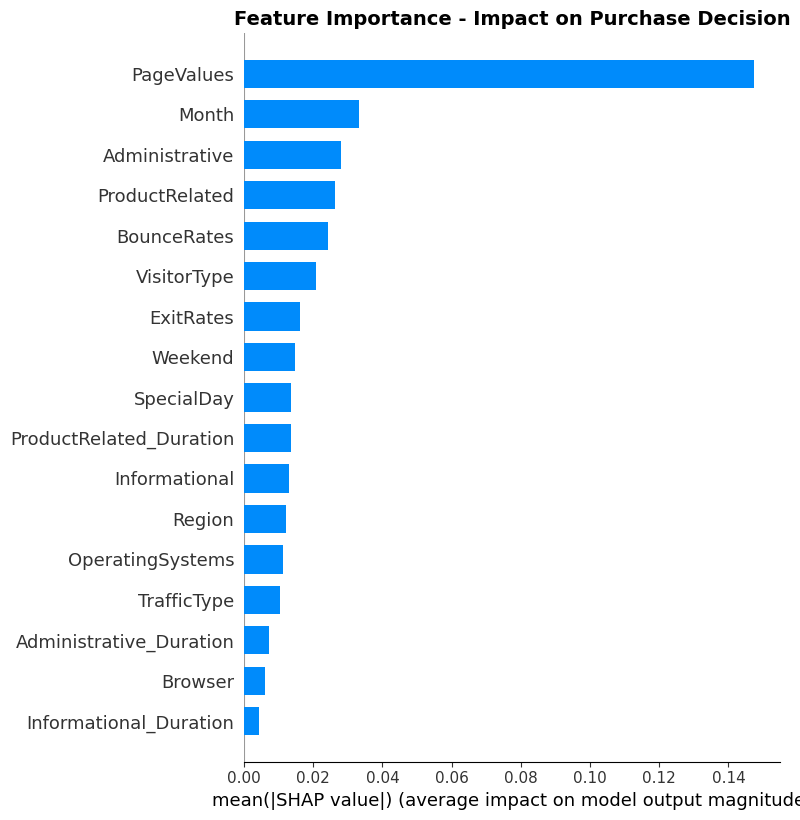

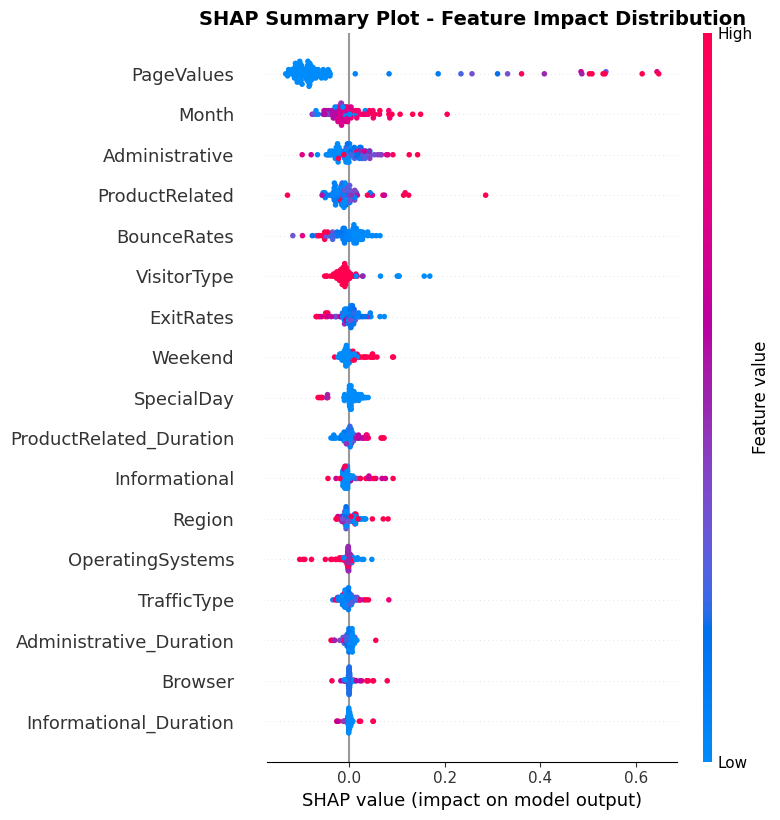


💡 SHAP ANALYSIS RESULTS:
------------------------------------------------------------
Interpretation:
• Red points = High feature value (positive impact on prediction)
• Blue points = Low feature value (negative impact on prediction)
• Position on X-axis = Magnitude of impact on model output

Business Insights:
• Features on the RIGHT have positive effect on purchase likelihood
• Features on the LEFT have negative effect on purchase likelihood
• This information can guide website optimization strategies
------------------------------------------------------------


In [6]:
import shap
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

feature_names = X.columns.tolist()

print("\n🔍 Analyzing feature importance with SHAP...")
print("This helps answer: WHY does the model predict purchase?")

background_sample = X_train[:100]  
explainer = shap.DeepExplainer(model, background_sample)

test_sample = X_test[:100]
shap_values = explainer.shap_values(test_sample, check_additivity=False)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 0]
# ====================================================

print("\n" + "="*60)
print("🌟 FEATURE IMPORTANCE VISUALIZATION 🌟")
print("="*60)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title('Feature Importance - Impact on Purchase Decision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 SHAP ANALYSIS RESULTS:")
print("-" * 60)
print("Interpretation:")
print("• Red points = High feature value (positive impact on prediction)")
print("• Blue points = Low feature value (negative impact on prediction)")
print("• Position on X-axis = Magnitude of impact on model output")
print("\nBusiness Insights:")
print("• Features on the RIGHT have positive effect on purchase likelihood")
print("• Features on the LEFT have negative effect on purchase likelihood")
print("• This information can guide website optimization strategies")
print("-" * 60)

